In this notebook, five CNN models are trained with TensorFlow/Keras for the classification task of infrared solar module images. The task is to classify each image as Faulty or Normal based on the local InfraredSolarModules dataset.

The models used are:

- AlexNet-style CNN
- ResNet18-style CNN
- EfficientNetB0
- DenseNet121
- VGG16

The notebook keeps the original binary classification target derived from anomaly_class while replacing the PyTorch training pipeline with TensorFlow/Keras. Because several Keras application models expect RGB inputs with a minimum spatial size, the grayscale images are resized to 64x64 and replicated to 3 channels during preprocessing.

Note: Verified with Tensorflow 2.15.x, Python 3.11


# Input library and dataset

In [1]:
import json
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid")
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

IMG_SIZE = (64, 64)
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 64
DEFAULT_EPOCHS = 1
AUTOTUNE = tf.data.AUTOTUNE

print(f'TensorFlow version: {tf.__version__}')
print('GPUs:', tf.config.list_physical_devices('GPU'))

2026-03-15 07:43:35.106105: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 07:43:35.556808: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 07:43:35.557427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 07:43:35.613087: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 07:43:35.772149: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.1
GPUs: []


In [2]:
import importlib
import platform


def _best_effort_set_memory_growth(tf_module, device_type):
    devices = tf_module.config.list_physical_devices(device_type)
    for device in devices:
        try:
            tf_module.config.experimental.set_memory_growth(device, True)
        except Exception:
            pass
    return devices


def _smoke_test_matmul(tf_module, device, n=1024):
    try:
        with tf.device(device):
            a = tf_module.random.normal([n, n])
            b = tf_module.random.normal([n, n])
            c = tf_module.matmul(a, b)
            _ = c[0, 0].numpy()
        return True, "ok"
    except Exception as exc:
        return False, repr(exc)


def configure_runtime_device(tf_module):
    print(f"Platform   : {platform.platform()}")
    print(f"TensorFlow : {tf_module.__version__}")

    try:
        gpus = _best_effort_set_memory_growth(tf_module, "GPU")
    except Exception:
        gpus = []
    if gpus:
        ok, info = _smoke_test_matmul(tf_module, "/GPU:0")
        if ok:
            return "/GPU:0", "cuda", [device.name for device in gpus], info
        print("CUDA present but failed smoke test ->", info)

    try:
        importlib.import_module("intel_extension_for_tensorflow")
        xpus = _best_effort_set_memory_growth(tf_module, "XPU")
    except Exception as exc:
        xpus = []
        print("ITEX/XPU not available:", repr(exc))

    if xpus:
        ok, info = _smoke_test_matmul(tf_module, "/XPU:0")
        if ok:
            return "/XPU:0", "xpu", [device.name for device in xpus], info
        print("XPU present but failed smoke test ->", info)

    return "/CPU:0", "cpu", [], "ok"


RUNTIME_DEVICE, BACKEND, ACCEL_NAMES, SMOKE_INFO = configure_runtime_device(tf)
print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
print(f"Devices    : {ACCEL_NAMES if ACCEL_NAMES else 'none detected -> CPU fallback'}")
print(f"Smoke test : {SMOKE_INFO}")

Platform   : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
TensorFlow : 2.15.1


2026-03-15 07:44:56.276252: I tensorflow/core/common_runtime/next_pluggable_device/next_pluggable_device_factory.cc:118] Created 1 TensorFlow NextPluggableDevices. Physical device type: XPU


Backend    : XPU (/XPU:0)
Devices    : ['/physical_device:XPU:0']
Smoke test : ok


In [3]:
def resolve_dataset_dir() -> Path:
    kaggle_dir = Path('/kaggle/input/infrared-solar-modules/2020-02-14_InfraredSolarModules/InfraredSolarModules')
    if kaggle_dir.exists():
        return kaggle_dir

    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        local_dataset = candidate / 'dataset' / '2020-02-14_InfraredSolarModules' / 'InfraredSolarModules'
        repo_dataset = candidate / 'classwork' / 'solar' / 'dataset' / '2020-02-14_InfraredSolarModules' / 'InfraredSolarModules'
        if local_dataset.exists():
            return local_dataset
        if repo_dataset.exists():
            return repo_dataset

    raise FileNotFoundError('Could not locate the InfraredSolarModules dataset from the current working directory.')


DATASET_DIR = resolve_dataset_dir()
METADATA_PATH = DATASET_DIR / 'module_metadata.json'

with METADATA_PATH.open() as handle:
    raw_metadata = json.load(handle)

df = pd.DataFrame.from_dict(raw_metadata, orient='index').sort_index().reset_index(names='module_id')
df['image_filepath'] = df['image_filepath'].map(lambda rel_path: str(DATASET_DIR / rel_path))
df['status'] = np.where(df['anomaly_class'].eq('No-Anomaly'), 'Normal', 'Faulty')
classification_type = 'status'
label_names = sorted(df[classification_type].unique())
label_to_id = {label: index for index, label in enumerate(label_names)}
df['label_id'] = df[classification_type].map(label_to_id)

print(f'Dataset directory: {DATASET_DIR}')
print(f'Metadata file exists: {METADATA_PATH.exists()}')
display(df.head())

Dataset directory: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules
Metadata file exists: True


,module_id,image_filepath,anomaly_class,status,label_id
0,0,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,Offline-Module,Faulty,0
1,1,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,Offline-Module,Faulty,0
2,10,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,Offline-Module,Faulty,0
3,100,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,Offline-Module,Faulty,0
4,1000,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,Diode-Multi,Faulty,0


In [4]:
display(df[classification_type].value_counts().rename('count').to_frame())
display(df['anomaly_class'].value_counts().rename('count').to_frame())

,count
status,
Faulty,10000
Normal,10000


,count
anomaly_class,
No-Anomaly,10000
Cell,1877
Vegetation,1639
Diode,1499
Cell-Multi,1288
Shadowing,1056
Cracking,940
Offline-Module,827
Hot-Spot,249


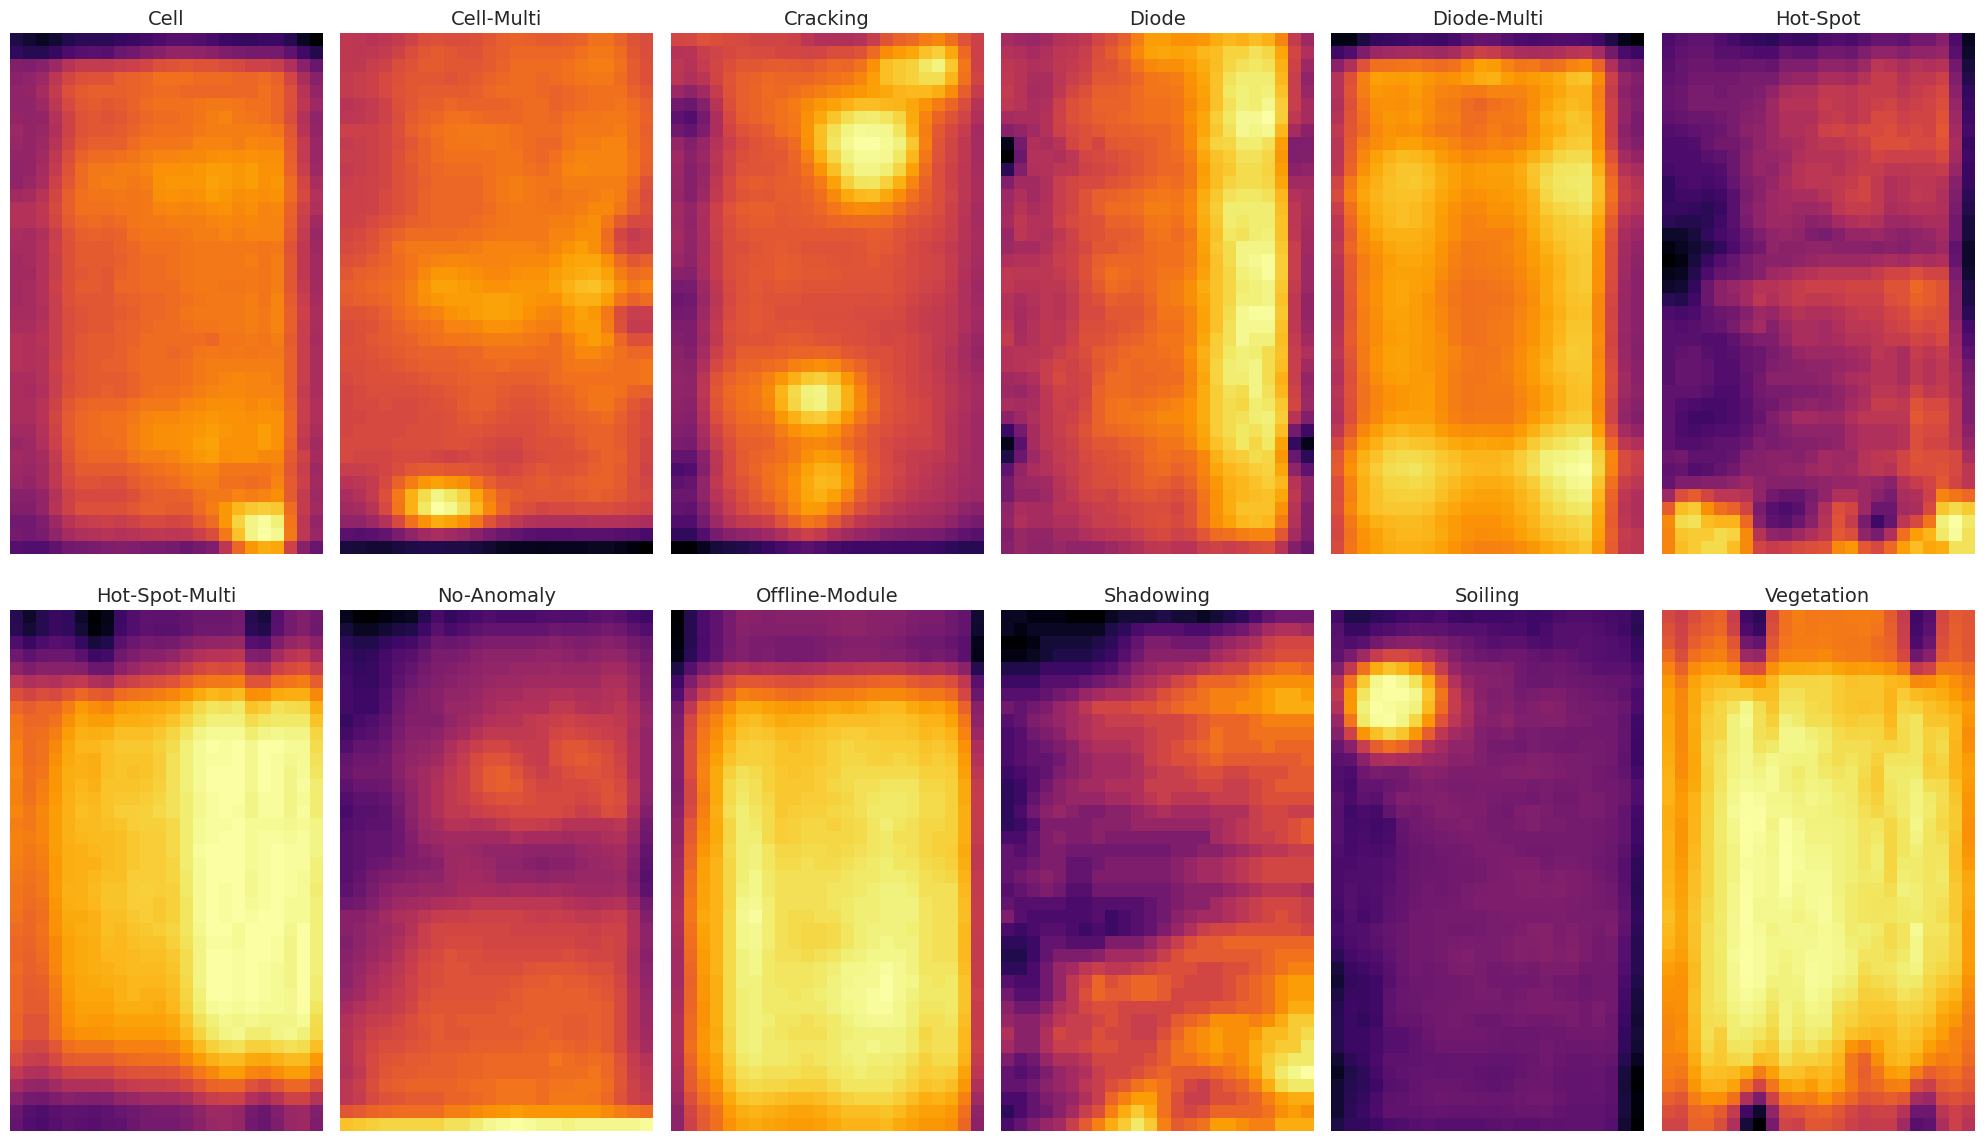

In [5]:
def plot_samples(anomaly_type='all', cmap='inferno'):
    if anomaly_type == 'all':
        sample = df.groupby('anomaly_class', group_keys=False).sample(n=1, random_state=42)
    else:
        subset = df[df['anomaly_class'] == anomaly_type]
        sample_size = min(12, len(subset))
        sample = subset.sample(sample_size, random_state=42)

    plt.figure(figsize=(20, 12))
    for index, (_, row) in enumerate(sample.iterrows(), start=1):
        image = np.array(Image.open(row['image_filepath']).convert('L'))
        plt.subplot(2, 6, index)
        plt.imshow(image, cmap=cmap)
        plt.title(row['anomaly_class'], fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


plot_samples()

In [6]:
def split_data(dataframe):
    df_train = pd.DataFrame(columns=dataframe.columns)
    df_test = pd.DataFrame(columns=dataframe.columns)
    df_val = pd.DataFrame(columns=dataframe.columns)

    dataframe = dataframe.sample(frac=1, random_state=42).reset_index(drop=True)

    for anomaly_class, group in dataframe.groupby('anomaly_class'):
        total = len(group)
        test_size = int(total * 0.14)
        val_size = int(total * 0.01)

        group = group.sample(frac=1, random_state=42).reset_index(drop=True)
        test_split = group.iloc[:test_size]
        val_split = group.iloc[test_size:test_size + val_size]
        train_split = group.iloc[test_size + val_size:]

        df_train = pd.concat([df_train, train_split], ignore_index=True)
        df_test = pd.concat([df_test, test_split], ignore_index=True)
        df_val = pd.concat([df_val, val_split], ignore_index=True)

    print('Train:', len(df_train), 'Test:', len(df_test), 'Val:', len(df_val))
    return df_train, df_test, df_val


df_train, df_test, df_val = split_data(df)
display(df_train[classification_type].value_counts().rename('train_count').to_frame())

Train: 17013 Test: 2793 Val: 194


,train_count
status,
Faulty,8513
Normal,8500


In [7]:
def preprocess_image(image_path, label, training=False):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_bytes, channels=1)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.image.convert_image_dtype(image, tf.float32)

    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.12)
        image = tf.clip_by_value(image, 0.0, 1.0)

    image = tf.image.grayscale_to_rgb(image)
    return image, label


def build_tf_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe['image_filepath'].astype(str).to_numpy(),
        dataframe['label_id'].astype(np.int32).to_numpy(),
    ))

    if training:
        dataset = dataset.shuffle(len(dataframe), seed=42, reshuffle_each_iteration=True)

    dataset = dataset.map(
        lambda image_path, label: preprocess_image(image_path, label, training=training),
        num_parallel_calls=AUTOTUNE,
    )
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = build_tf_dataset(df_train, training=True)
val_ds = build_tf_dataset(df_val)
test_ds = build_tf_dataset(df_test)

sample_images, sample_labels = next(iter(train_ds))
print('Batch image shape:', sample_images.shape)
print('Batch label shape:', sample_labels.shape)

Batch image shape: (64, 64, 64, 3)
Batch label shape: (64,)


# Models

In [8]:
def build_alexnet(input_shape=INPUT_SHAPE, num_classes=2):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='AlexNet')


def residual_block(inputs, filters, stride=1, projection=False):
    shortcut = inputs

    x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if projection or stride != 1 or inputs.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)


def build_resnet18(input_shape=INPUT_SHAPE, num_classes=2):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, kernel_size=3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2, projection=True)
    x = residual_block(x, 128)
    x = residual_block(x, 256, stride=2, projection=True)
    x = residual_block(x, 256)
    x = residual_block(x, 512, stride=2, projection=True)
    x = residual_block(x, 512)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='ResNet18')


def build_efficientnet(input_shape=INPUT_SHAPE, num_classes=2):
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=None,
        input_shape=input_shape,
        pooling='avg',
    )
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='EfficientNetB0')


def build_densenet(input_shape=INPUT_SHAPE, num_classes=2):
    base_model = keras.applications.DenseNet121(
        include_top=False,
        weights=None,
        input_shape=input_shape,
        pooling='avg',
    )
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='DenseNet121')


def build_vgg16(input_shape=INPUT_SHAPE, num_classes=2):
    base_model = keras.applications.VGG16(
        include_top=False,
        weights=None,
        input_shape=input_shape,
        pooling='avg',
    )
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='VGG16')


MODEL_BUILDERS = [build_alexnet, build_resnet18, build_efficientnet, build_densenet, build_vgg16]

# Train

In [9]:
CHECKPOINT_DIR = Path('tensorflow_checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)


def plot_history(history, model_name):
    history_frame = pd.DataFrame(history.history)
    best_epoch = int(history_frame['val_accuracy'].idxmax()) + 1

    _, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].plot(history_frame.index + 1, history_frame['accuracy'], label='Training', linestyle='--', color='navy')
    axes[0].plot(history_frame.index + 1, history_frame['val_accuracy'], label='Validation', color='orangered')
    axes[0].scatter(best_epoch, history_frame.loc[best_epoch - 1, 'val_accuracy'], color='black', s=80, label='Best epoch')
    axes[0].set_title(f'{model_name} Accuracy Trend')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history_frame.index + 1, history_frame['loss'], label='Training', linestyle='--', color='navy')
    axes[1].plot(history_frame.index + 1, history_frame['val_loss'], label='Validation', color='orangered')
    axes[1].set_title(f'{model_name} Loss Trend')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion(model, dataset, labels):
    y_true = np.concatenate([target.numpy() for _, target in dataset], axis=0)
    with tf.device(RUNTIME_DEVICE):
        y_pred = model.predict(dataset, verbose=0).argmax(axis=1)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix')
    plt.show()


def train_and_evaluate_model(model, num_epochs=DEFAULT_EPOCHS, patience=5):
    with tf.device(RUNTIME_DEVICE):
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )

    checkpoint_path = CHECKPOINT_DIR / f'{model.name}_best.keras'
    checkpoint_path_str = str(checkpoint_path)
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path_str,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    start_time = time.time()
    with tf.device(RUNTIME_DEVICE):
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=num_epochs,
            callbacks=callbacks,
            verbose=1,
        )
    elapsed = time.time() - start_time

    with tf.device(RUNTIME_DEVICE):
        best_model = keras.models.load_model(checkpoint_path_str)
        test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=0)

    plot_history(history, model.name)
    plot_confusion(best_model, test_ds, label_names)

    metrics = {
        'model': model.name,
        'epochs_ran': len(history.history['loss']),
        'best_val_accuracy': float(np.max(history.history['val_accuracy'])),
        'best_val_loss': float(np.min(history.history['val_loss'])),
        'test_loss': float(test_loss),
        'test_accuracy': float(test_accuracy),
        'training_time_sec': float(elapsed),
    }

    print(f"Runtime device: {RUNTIME_DEVICE} ({BACKEND})")
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy * 100:.2f}%")
    return best_model, history, metrics

# Results


Started training model: AlexNet on /XPU:0


2026-03-15 07:45:19.134784: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type XPU is enabled.


onednn_verbose,v1,info,oneDNN v3.8.0 (commit 5dc2e69f319ab59520c9096436488c11ab86fd93)
onednn_verbose,v1,info,cpu,runtime:DPC++,nthr:1
onednn_verbose,v1,info,cpu,isa:Intel AVX2 with Intel DL Boost, float16 and bfloat16 support
onednn_verbose,v1,info,gpu,runtime:DPC++
onednn_verbose,v1,info,cpu,engine,sycl cpu device count:1 
onednn_verbose,v1,info,cpu,engine,0,backend:OpenCL,name:Intel(R) Core(TM) Ultra 9 288V,driver_version:2026.20.1
onednn_verbose,v1,info,gpu,engine,sycl gpu device count:1 
onednn_verbose,v1,info,gpu,engine,0,backend:Level Zero,name:Intel(R) Graphics [0x64a0],driver_version:1.14.37020,binary_kernels:enabled
onednn_verbose,v1,info,graph,backend,0:dnnl_backend
onednn_verbose,v1,info,experimental features are enabled
onednn_verbose,v1,info,use batch_normalization stats one pass is enabled
onednn_verbose,v1,info,GPU convolution v2 is disabled
onednn_verbose,v1,info,experimental functionality for sparse domain is enabled
onednn_verbose,v1,primitive,info,template:operation

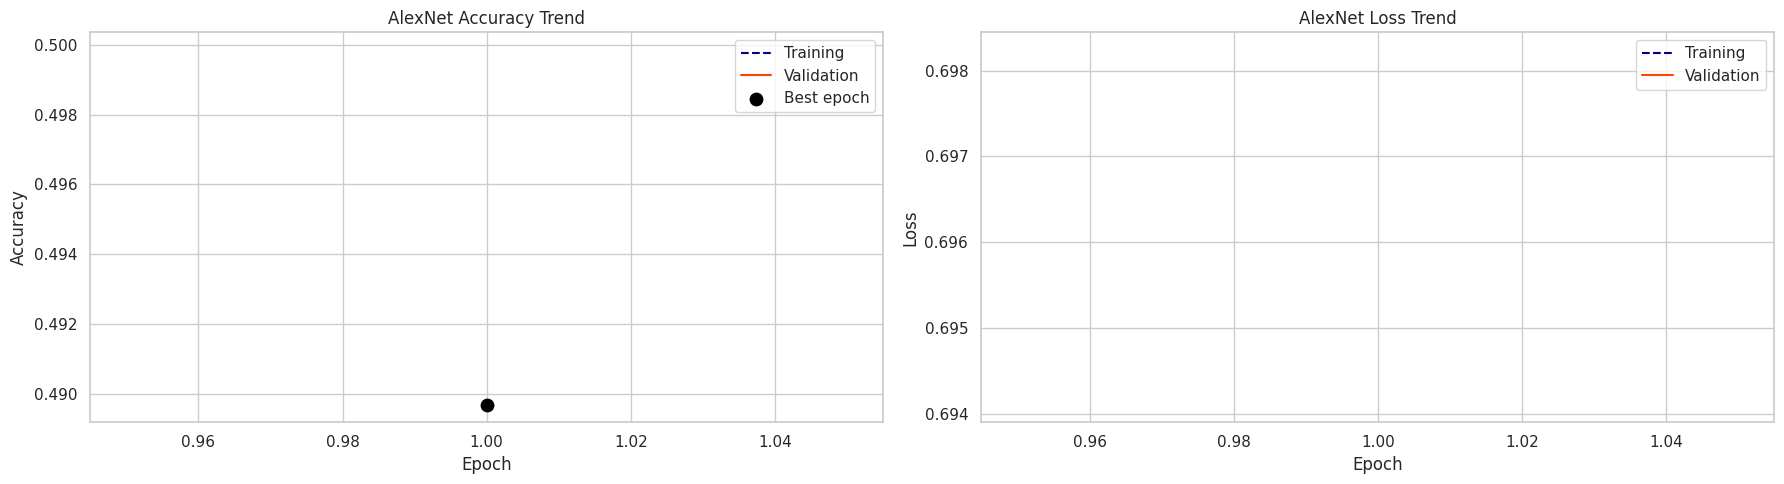

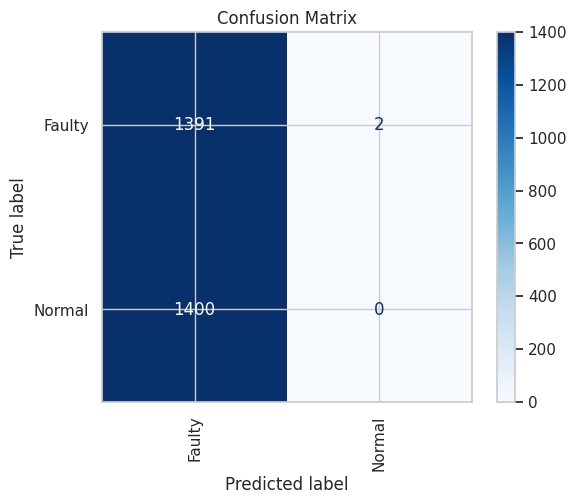

Runtime device: /XPU:0 (xpu)
Test Loss: 0.6933, Test Accuracy: 49.80%

Started training model: ResNet18 on /XPU:0
189/266 [====================>.........] - ETA: 2:57 - loss: 0.7448 - accuracy: 0.4990

: 

: 

In [10]:
results = []
trained_models = {}
history_by_model = {}

for builder in MODEL_BUILDERS:
    tf.keras.backend.clear_session()
    with tf.device(RUNTIME_DEVICE):
        model = builder(input_shape=INPUT_SHAPE, num_classes=len(label_names))
    print(f'\nStarted training model: {model.name} on {RUNTIME_DEVICE}')
    best_model, history, metrics = train_and_evaluate_model(model, num_epochs=DEFAULT_EPOCHS)
    trained_models[model.name] = best_model
    history_by_model[model.name] = pd.DataFrame(history.history)
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
results_df['best_val_accuracy_pct'] = results_df['best_val_accuracy'] * 100.0
results_df['test_accuracy_pct'] = results_df['test_accuracy'] * 100.0

display(results_df)

if not results_df.empty:
    best_model_name = results_df.loc[0, 'model']
    print(f"Best model by test accuracy: {best_model_name} ({results_df.loc[0, 'test_accuracy_pct']:.2f}%)")

# Comparison and review

The PyTorch notebook ends with a full model-training pass. This TensorFlow version adds a compact comparison view and a best-model review section so the notebook is complete after training finishes.

In [ ]:
if 'results_df' not in globals() or results_df.empty:
    raise ValueError('Run the training/results cell before this comparison cell.')

comparison_df = results_df[[
    'model',
    'epochs_ran',
    'best_val_accuracy_pct',
    'test_accuracy_pct',
    'test_loss',
    'training_time_sec',
]].copy()

display(
    comparison_df.style.format({
        'best_val_accuracy_pct': '{:.2f}%',
        'test_accuracy_pct': '{:.2f}%',
        'test_loss': '{:.4f}',
        'training_time_sec': '{:.1f}s',
    })
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=results_df, x='test_accuracy_pct', y='model', ax=axes[0], palette='crest')
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_ylabel('Model')

sns.barplot(data=results_df, x='test_loss', y='model', ax=axes[1], palette='flare')
axes[1].set_title('Test Loss by Model')
axes[1].set_xlabel('Loss')
axes[1].set_ylabel('')

sns.barplot(data=results_df, x='training_time_sec', y='model', ax=axes[2], palette='mako')
axes[2].set_title('Training Time by Model')
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, 'model']
best_history = history_by_model[best_model_name]
display(best_history.tail())

In [ ]:
if 'results_df' not in globals() or results_df.empty:
    raise ValueError('Run the training/results cell before reviewing predictions.')

def show_sample_predictions(model, dataframe, sample_size=12, cmap='inferno'):
    sample_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=42).reset_index(drop=True)
    sample_ds = build_tf_dataset(sample_df, training=False)

    with tf.device(RUNTIME_DEVICE):
        probabilities = model.predict(sample_ds, verbose=0)

    predicted_ids = probabilities.argmax(axis=1)
    predicted_labels = [label_names[index] for index in predicted_ids]
    faulty_index = label_to_id['Faulty']

    num_samples = len(sample_df)
    num_cols = 4
    num_rows = int(np.ceil(num_samples / num_cols))
    plt.figure(figsize=(18, 4 * num_rows))

    for index, (_, row) in enumerate(sample_df.iterrows(), start=1):
        image = np.array(Image.open(row['image_filepath']).convert('L'))
        predicted_label = predicted_labels[index - 1]
        faulty_probability = probabilities[index - 1, faulty_index]
        is_correct = predicted_label == row[classification_type]

        plt.subplot(num_rows, num_cols, index)
        plt.imshow(image, cmap=cmap)
        plt.title(
            f"True: {row[classification_type]}\nPred: {predicted_label}\nP(Faulty): {faulty_probability:.2f}",
            color='darkgreen' if is_correct else 'crimson',
            fontsize=11,
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()


best_model_name = results_df.loc[0, 'model']
best_model = trained_models[best_model_name]
show_sample_predictions(best_model, df_test)